In [11]:
from dataloader.Dataloader import *
from model.Classifier import *

In [12]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model = Classifier(out_dim=512).to(device) 

In [13]:
train_tsv_file = "data/CrisisMMD_v2.0/crisismmd_datasplit_all/task_humanitarian_text_img_train.tsv"
val_tsv_file = "data/CrisisMMD_v2.0/crisismmd_datasplit_all/task_humanitarian_text_img_dev.tsv"
img_dir = "data/CrisisMMD_v2.0"

train_dataset = CrisisDataset(train_tsv_file, "data/CrisisMMD_v2.0", model.clip_preprocess)
val_dataset = CrisisDataset(val_tsv_file, "data/CrisisMMD_v2.0", model.clip_preprocess)

In [14]:
class_names = [
    "infrastructure and utility damage",
    "not humanitarian",
    "rescue volunteering or donation effort",
    "other relevant information",
    "affected individuals",
    "injured or dead people",
    "vehicle damage",
    "missing or found people"
]

class_prompts = [
    "an image and tweet about infrastructure and utility damage after a disaster",
    "an image and tweet not related to humanitarian disaster",
    "an image and tweet about rescue, volunteering, or donation effort after a disaster",
    "an image and tweet about other relevant disaster information",
    "an image and tweet about affected individuals after a disaster",
    "an image and tweet about injured or dead people after a disaster",
    "an image and tweet about vehicle damage after a disaster",
    "an image and tweet about missing or found people after a disaster"
]

with torch.no_grad():
    class_tokens = clip.tokenize(class_prompts, truncate=True).to(model.device)
    class_features = model.clip_encoder.encode_text(class_tokens)
    class_features = class_features / class_features.norm(dim=-1, keepdim=True)
    class_features = class_features.float()

print(class_features.shape)

torch.Size([8, 512])


In [15]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2
)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.proj.parameters(), lr=1e-3)

n_epochs = 20

In [16]:
from tqdm import tqdm

def evaluate(model, val_loader, class_features, criterion):
    model.eval()

    total_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        pbar = tqdm(val_loader, desc="Validation")

        for batch in pbar:
            images = batch["image"]
            texts = batch["text"]
            labels = batch["label"].to(model.device)

            # Forward
            sample_features = model(images, texts)   # [B, 512]

            logits = sample_features @ class_features.T

            loss = criterion(logits, labels)

            # Metrics
            total_loss += loss.item() * labels.size(0)
            preds = logits.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

            pbar.set_postfix({
                "loss": loss.item(),
                "acc": correct / total
            })

    val_loss = total_loss / total
    val_acc = correct / total

    return val_loss, val_acc

In [17]:
train_losses = []
train_accs = []

val_losses = []
val_accs = []

best_val_acc = 0.0

for epoch in range(n_epochs):
    model.train()

    total_loss = 0.0
    correct = 0
    total = 0

    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{n_epochs}")

    for batch in pbar:
        images = batch["image"]
        texts = batch["text"]
        labels = batch["label"].to(model.device)

        sample_features = model(images, texts)
        logits = 10.0 * (sample_features @ class_features.T)

        loss = criterion(logits, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * labels.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

        pbar.set_postfix({
            "loss": loss.item(),
            "acc": correct / total
        })

    epoch_loss = total_loss / total
    epoch_acc = correct / total

    train_losses.append(epoch_loss)
    train_accs.append(epoch_acc)

    val_loss, val_acc = evaluate(model, val_loader, class_features, criterion)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_model.pth")
        print("Saved best model!")

    val_losses.append(val_loss)
    val_accs.append(val_acc)

    print(
        f"Epoch {epoch+1}: "
        f"train_loss={epoch_loss:.4f}, train_acc={epoch_acc:.4f} | "
        f"val_loss={val_loss:.4f}, val_acc={val_acc:.4f}"
    )

Validation: 100%|██████████| 70/70 [00:21<00:00,  3.19it/s, loss=1.91, acc=0.623]


Saved best model!
Epoch 1: train_loss=1.2502, train_acc=0.5874 | val_loss=1.9388, val_acc=0.6227


Validation: 100%|██████████| 70/70 [00:21<00:00,  3.19it/s, loss=1.92, acc=0.633]


Saved best model!
Epoch 2: train_loss=1.1376, train_acc=0.6334 | val_loss=1.9382, val_acc=0.6330


Validation: 100%|██████████| 70/70 [00:26<00:00,  2.66it/s, loss=1.94, acc=0.637]


...

Epoch 18: train_loss=0.5536, train_acc=0.9339 | val_loss=1.9455, val_acc=0.5865


Validation: 100%|██████████| 70/70 [00:22<00:00,  3.06it/s, loss=1.93, acc=0.573]


Epoch 19: train_loss=0.5494, train_acc=0.9335 | val_loss=1.9495, val_acc=0.5731


Validation: 100%|██████████| 70/70 [00:23<00:00,  2.93it/s, loss=1.95, acc=0.573]

Epoch 20: train_loss=0.5352, train_acc=0.9403 | val_loss=1.9503, val_acc=0.5726


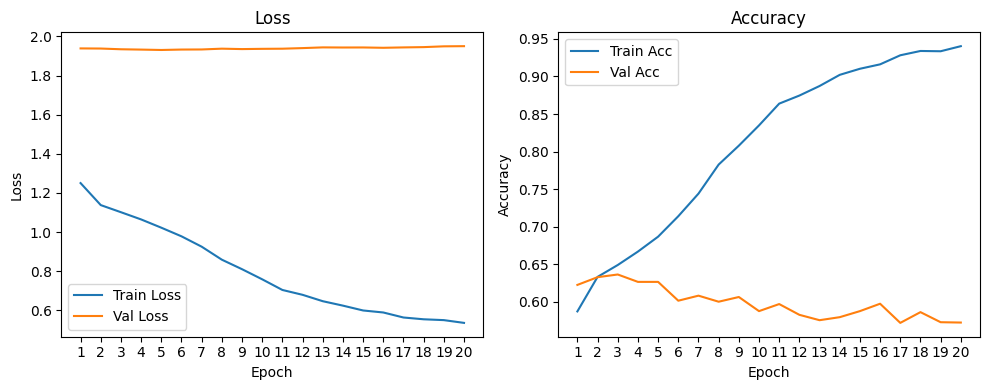

In [19]:
import matplotlib.pyplot as plt

epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(10, 4))

# --- Loss ---
plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, label="Train Loss")
plt.plot(epochs, val_losses, label="Val Loss")
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.xticks(epochs)   
plt.legend()

# --- Accuracy ---
plt.subplot(1, 2, 2)
plt.plot(epochs, train_accs, label="Train Acc")
plt.plot(epochs, val_accs, label="Val Acc")
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.xticks(epochs)   
plt.legend()

plt.tight_layout()
plt.show()